# Roos two-ion quadrupole-slope case: an ion-clock benchmark

This notebook walks the Ca+:D5/2 electric-quadrupole-shift case against
Roos et al.'s (quant-ph/0701215v1, published Nature 443, 316 (2006))
measured two-ion parity-oscillation slope. Two variants come out of the
same engine functions and carry distinct labels: the headline
**`"cross_vintage_comparison"`** uses Itano's independent theory value
for the quadrupole moment, a different vintage and method from Roos's
own measurement; the secondary **`"arithmetic_reproduction"`** uses
Roos's own extracted quadrupole moment, inverted from the very fit this
case predicts, so it closes the loop by construction and checks nothing
external. The governing equation, the two competing
quadrupole-moment inputs, the pipeline stages that combine them into a
two-ion slope, and the comparison against Roos's measurement follow in
order below.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import loaders
import run_roos_quadrupole_slope as roos

from cliffordclock.ensemble.species import ION_MICROMOTION_NOTES, QUADRUPOLE_MOMENTS
from cliffordclock.integrator.omega import quadrupole_mj_factor, quadrupole_shift_joules

## 1. The physics: the electric-quadrupole level shift (E34/E35)

A D-state ion clock's upper level is not spherically symmetric the way
an S-state is: it carries a permanent electric-quadrupole moment,
`Theta(J)`, that couples directly to any electric-field gradient present
at the ion, at first order, unlike the second-order mechanism E14b
describes for a scalar polarizability. `docs/CONVENTIONS.md`'s E34
(section 14) writes the resulting level shift as `Theta_SI(J)/2` times an
angular factor that depends only on the state's `(J, m_J)`, times the
gradient tensor contracted along the ion's quantization axis; E35 then
composes that shift additively into the same scalar pivot `P(r) - 1` the
DC-Stark and BBR terms occupy, since it is just one more contribution to
the clock's fractional frequency at a point. The angular factor's sign
and magnitude depend on `m_J`, which is the whole reason a *pair* of
entangled ions in different `m_J` states produces a parity-oscillation
signal at all: each ion's own quadrupole shift differs, and the
difference between the two states' total energies is what oscillates.

## 2. The inputs: two quadrupole moments, one applied gradient

Roos et al. applied a mechanically calibrated axial gradient (from the
ion's own measured secular frequency, `dE_z/dz` between 12 and 48
`V/mm^2` across their dataset, with a canonical single point at 30
`V/mm^2` used here) to a two-ion Ca+:D5/2 crystal, at quantization angle
`beta = 0`, and fit the resulting parity-oscillation slope. Two
quadrupole-moment values compete to predict that same slope: Itano's
independent ab-initio theory value (a different vintage and method from
Roos's own fit) and Roos's own value, extracted by inverting their own
measured slope through the very relation this case predicts. Because a
second trapped ion doubles the gradient at its neighbor's location
(Roos's own stated geometry), every single-ion evaluation below uses
twice the applied gradient. Section 3c below divides back out by the
single applied gradient to produce the reported slope, so the doubling
and its removal both stay visible in the pipeline.

In [2]:
moment = QUADRUPOLE_MOMENTS["Ca+:D5/2"]
print(f"J (D5/2):                    {moment.j}")
print(f"Roos's own Theta:            {moment.theta_au} +/- {moment.theta_au_uncertainty} ea0^2")
print(f"  source: {moment.source}")
print(f"Itano's theory Theta:        {moment.theory_theta_au} ea0^2")
print(f"  source: {moment.theory_source}")
print()
print(f"canonical applied gradient:  {roos.CANONICAL_APPLIED_GRADIENT_VMM2} V/mm^2 (Roos Fig. 4a)")

measured = loaders.ROOS_MEASURED_SLOPE_HZ_MM2_PER_V
print(f"measured slope (Roos Fig. 4a): {measured.nominal} Hz*mm^2/V")
print(f"  citation: {measured.citation}")

J (D5/2):                    2.5
Roos's own Theta:            1.83 +/- 0.01 ea0^2
  source: Roos et al., quant-ph/0701215v1 (Nature 443, 316 (2006)), Eq. 1 fit
Itano's theory Theta:        1.917 ea0^2
  source: Itano, Phys. Rev. A 73, 022510 (2006)

canonical applied gradient:  30.0 V/mm^2 (Roos Fig. 4a)
measured slope (Roos Fig. 4a): 2.975 Hz*mm^2/V
  citation: Roos, Chwalla, Kim, Riebe, Blatt, 'Designer atoms for quantum metrology,' quant-ph/0701215v1 (Nature 443, 316 (2006)), Fig. 4a + p.9: linear-fit slope "a = 2.975(2) Hz mm^2/V" of the measured two-ion quadrupole shift against the applied, omega_z-calibrated axial gradient dE_z/dz = 12-48 V/mm^2 at beta=0 -- see Roos et al., Nature 443, 316 (2006), quant-ph/0701215v1, Eq. 1/Fig. 4a.


## 3. The pipeline, staged

Every case number below comes from real calls into
`cliffordclock.integrator.omega.quadrupole_mj_factor`/
`quadrupole_shift_joules`, the same functions
`run_roos_quadrupole_slope.py` itself calls internally to build the
case, run here one stage at a time so the intermediate single-ion shifts
are visible before they are combined into a two-ion slope.

Unlike notebooks 06, 07, and 09, there is no field-import or
config-building stage here: the quadrupole shift couples to an
applied gradient directly, so this walkthrough drives the engine's
quadrupole functions with Roos's published gradient values instead
of routing a field file through the pipeline.


### 3a. The angular factor, per `m_J`

The two-ion `Psi_1` state Roos measures is a superposition of two
product states, `|-5/2>|+3/2>` and `|-1/2>|-1/2>`; the parity-oscillation
frequency is the energy difference between them, so it needs the
angular factor at each of the three distinct `m_J` values involved.

In [3]:
for m_j in (-2.5, 1.5, -0.5):
    factor = quadrupole_mj_factor(j=2.5, m_j=m_j)
    print(f"quadrupole_mj_factor(j=2.5, m_j={m_j:+.1f}) = {factor:+.4f}")

quadrupole_mj_factor(j=2.5, m_j=-2.5) = -1.0000
quadrupole_mj_factor(j=2.5, m_j=+1.5) = +0.2000
quadrupole_mj_factor(j=2.5, m_j=-0.5) = +0.8000


### 3b. Single-ion shifts at the doubled gradient

`quadrupole_shift_joules` takes the full gradient *tensor*, not just its
axial component, so a traceless axially symmetric tensor with
`dE_z/dz` along the lab z-axis is built first (beta=0, Roos's own
geometry); the function itself removes the trace and contracts against
the quantization axis. Passing in a tensor that is already traceless
here is a convenience for this walkthrough; the function computes
correctly from any gradient tensor, since it removes the trace
internally regardless of what arrives.

In [4]:
def axial_gradient_tensor(dez_dz_v_per_m2):
    g = float(dez_dz_v_per_m2)
    return jnp.array([[-g / 2.0, 0.0, 0.0], [0.0, -g / 2.0, 0.0], [0.0, 0.0, g]])


z_axis = jnp.array([0.0, 0.0, 1.0])
vmm2_to_vm2 = 1.0e6  # (V/mm^2) -> (V/m^2), Roos's Fig. 4a axis units to SI
doubled_gradient_v_per_m2 = 2.0 * roos.CANONICAL_APPLIED_GRADIENT_VMM2 * vmm2_to_vm2
grad_tensor = axial_gradient_tensor(doubled_gradient_v_per_m2)

single_ion_shifts_itano = {
    m_j: float(quadrupole_shift_joules(grad_tensor, z_axis, moment.theory_theta_au, moment.j, m_j))
    for m_j in (-2.5, 1.5, -0.5)
}
for m_j, shift in single_ion_shifts_itano.items():
    print(f"Delta_E_Q(m_J={m_j:+.1f}), Itano Theta: {shift:+.4e} J")

Delta_E_Q(m_J=-2.5), Itano Theta: -2.5802e-32 J
Delta_E_Q(m_J=+1.5), Itano Theta: +5.1604e-33 J
Delta_E_Q(m_J=-0.5), Itano Theta: +2.0642e-32 J


### 3c. Combining into the two-ion splitting and the predicted slope

The two-ion energy splitting is the sum of the `|-5/2>` and `|+3/2>`
single-ion shifts minus twice the `|-1/2>` shift (`two_ion_hbar_delta1_joules`,
called directly below since it is the same
four-call combination the cells above just built up by hand, so it needs
no re-derivation here), turned
into a slope by dividing the resulting frequency by the applied (not
doubled) gradient. The structural check first: the two-ion enhancement
over a single `|-5/2>` ion's shift at the same applied gradient must
equal exactly `24/5`, independent of the quadrupole moment's value or
sign, since it is a pure angular-factor ratio.

In [5]:
ratio = roos.structural_two_ion_enhancement_ratio()
print(f"engine-recovered enhancement ratio: {ratio:+.6f}  (must equal +24/5 = +4.8)")
print()

for label, theta_au in (("Itano theory", moment.theory_theta_au), ("Roos's own", moment.theta_au)):
    slope = roos.predicted_slope_hz_mm2_per_v(theta_au)
    print(f"predicted slope ({label}, Theta={theta_au} ea0^2): {slope:.6f} Hz*mm^2/V")

engine-recovered enhancement ratio: +4.800000  (must equal +24/5 = +4.8)

predicted slope (Itano theory, Theta=1.917 ea0^2): 3.115229 Hz*mm^2/V
predicted slope (Roos's own, Theta=1.83 ea0^2): 2.973849 Hz*mm^2/V


### 3d. The wrapped case function reproduces the same headline numbers

`run_roos_quadrupole_slope_case()` builds both variants from exactly the
functions exercised above and packages them against Roos's own measured
slope, including each variant's binding classification label.

In [6]:
case = roos.run_roos_quadrupole_slope_case()
cv = case.cross_vintage
ar = case.arithmetic_reproduction

for label, variant in (
    ("cross-vintage (headline)", cv),
    ("arithmetic reproduction (secondary)", ar),
):
    print(f"--- {label} ---")
    print(f"  case_class:       {variant.case_class!r}")
    print(f"  Theta (input):    {variant.theta_au} ea0^2")
    print(f"  predicted slope:  {variant.predicted_slope_hz_mm2_per_v:.6f} Hz*mm^2/V")
    print(f"  measured slope:   {variant.measured_slope_hz_mm2_per_v} Hz*mm^2/V")
    print(f"  residual:         {variant.residual_fractional:+.4%}")
    print(f"  kpi_verdict:      {variant.kpi_verdict}")
    if variant.verdict_note:
        print(f"  note:             {variant.verdict_note}")
    print()

itano_slope_recheck = roos.predicted_slope_hz_mm2_per_v(moment.theory_theta_au)
print(
    "consistency with the staged calls above: "
    f"{abs(cv.predicted_slope_hz_mm2_per_v - itano_slope_recheck) < 1e-9}"
)

--- cross-vintage (headline) ---
  case_class:       'cross_vintage_comparison'
  Theta (input):    1.917 ea0^2
  predicted slope:  3.115229 Hz*mm^2/V
  measured slope:   2.975 Hz*mm^2/V
  residual:         +4.7136%
  kpi_verdict:      NOT MET
  note:             NOT MET is the EXPECTED outcome for this variant: the residual recovers the literature-known ~4.7% Theta theory-vs-measurement tension (Itano theory 1.917 ea0^2 vs Roos's measured 1.83(1) ea0^2), validating the engine's factor chain while isolating the coefficient. It is not an engine defect. See the case write-up in benchmarks/RESULTS.md and the module docstring.

--- arithmetic reproduction (secondary) ---
  case_class:       'arithmetic_reproduction'
  Theta (input):    1.83 ea0^2
  predicted slope:  2.973849 Hz*mm^2/V
  measured slope:   2.975 Hz*mm^2/V
  residual:         -0.0387%
  kpi_verdict:      MET

consistency with the staged calls above: True


## 4. The comparison

The cross-vintage variant's `"NOT MET"` verdict is the expected
outcome. It recovers the literature's own known ~4.7% tension between
Itano's independent theory value and Roos's own measured quadrupole
moment: that tension lives entirely in the quadrupole-moment
coefficient's own uncertainty, and the factor chain built above carries
none of it. The arithmetic-reproduction variant closes the loop by
construction (Roos's own Theta was extracted by inverting this exact
relation from this exact measurement) and, unsurprisingly, lands close.
Neither variant is a `"reproducibility"` or `"blind_prediction"` case in
this project's taxonomy: both stronger classes need a field measured
independently of the applied-gradient calculation itself, and Roos's
own applied gradient is calibrated from the ion's mechanically measured
secular frequency, the same measurement the case evaluates. No
independent field measurement enters this case.

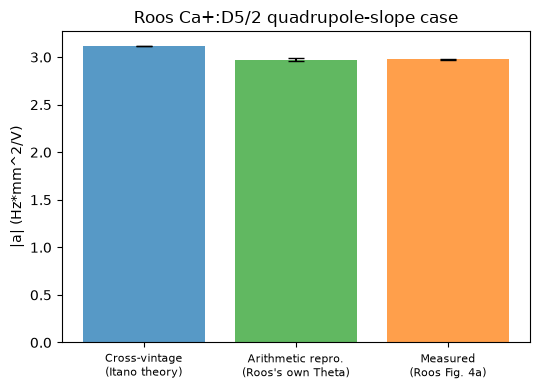

In [7]:
labels = [
    "Cross-vintage\n(Itano theory)",
    "Arithmetic repro.\n(Roos's own Theta)",
    "Measured\n(Roos Fig. 4a)",
]
values = [
    cv.predicted_slope_hz_mm2_per_v,
    ar.predicted_slope_hz_mm2_per_v,
    cv.measured_slope_hz_mm2_per_v,
]
errors = [
    max(cv.predicted_slope_band_hi - cv.predicted_slope_hz_mm2_per_v, 0.0),
    ar.predicted_slope_band_hi - ar.predicted_slope_hz_mm2_per_v,
    cv.measured_slope_hi - cv.measured_slope_hz_mm2_per_v,
]
colors = ["C0", "C2", "C1"]

fig, ax = plt.subplots(figsize=(5.5, 4.0))
x_pos = np.arange(3)
ax.bar(x_pos, values, yerr=errors, color=colors, alpha=0.75, capsize=6)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("|a| (Hz*mm^2/V)")
ax.set_title("Roos Ca+:D5/2 quadrupole-slope case")
fig.tight_layout()
plt.show()

## 5. What this demonstrates

This case shows the engine's quadrupole-shift functions correctly
reproducing the two-ion structural physics (the exact `24/5`
enhancement) and, in the cross-vintage variant, an independent theory
quadrupole moment predicting Roos's measured slope to within the
field's own known ~4.7% theory-vs-measurement tension. The one caveat
worth carrying alongside every number in this notebook is shared with
every other ion result this engine reports: the same stray field that
would produce a modeled quadrupole or DC-Stark shift also displaces a
real RF-trapped ion into excess micromotion, a separate, larger, and
currently unmodeled pathway, shown below in the exact wording this
project's ion reports carry. RF/micromotion support stays a tracked
roadmap item (`docs/roadmap.md`). This notebook's scope ends at the
quadrupole and DC-Stark shift functions it exercises above; whether the
engine also models micromotion-induced shifts is the separate, open
question that roadmap item tracks.

In [8]:
print(ION_MICROMOTION_NOTES["Al27+"])

Micromotion boundary (out of scope): the same stray DC field this tool's DC-Stark/quadrupole terms model also displaces the ion from the RF null, producing excess micromotion (time-dilation + AC-Stark from the trap RF) -- a separate, unmodeled pathway sourced by the SAME field. Al27+ is J=0 -> J=0: no first-order quadrupole term exists at all, so this tool characterizes essentially none of the ion's field-sensitive systematic budget, which is dominated by excess micromotion -45.8(5.9)e-19 + secular motion -17.3(2.9)e-19 (Brewer et al., Phys. Rev. Lett. 123, 033201 (2019), PRIMARY). A DC-Stark number alone is not a stray-field budget (canonical treatment: Berkeland, Miller, Bergquist, Itano, Wineland, J. Appl. Phys. 83, 5025 (1998); mechanism restated in Ludlow et al., Rev. Mod. Phys. 87, 637 (2015)).


## Where to go next

- `docs/validation.md`: the full case-by-case validation record.
- `benchmarks/RESULTS.md`: the full Roos write-up, the classification
  taxonomy, and the binding labeling rationale (G8 sign-off B4).
- `README.md`: the shipped ion-clock capability checklist entry.